<a href="https://colab.research.google.com/github/Sakshi-coder1/workco/blob/main/DSP_4_%26_5_(day).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# To resolve the 'NameError: name 'df' is not defined', please ensure you run the cell
# where 'df' is loaded (cell e04wBFFc_byw) before running any cells that use 'df',
# such as the plotting cell (NwwxPirh-Zc6).
import numpy as numpy
import pandas as pd

In [4]:
df=pd.read_csv("Day 3 .csv")

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

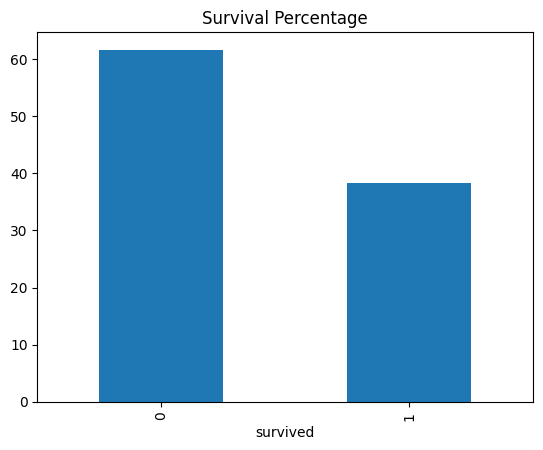

In [6]:
#Survial Rate
survial_rate=df["survived"].value_counts(normalize=True)*100
survial_rate.plot(kind="bar")
plt.title("Survival Percentage")
plt.show()

In [7]:
# Survial Percentage=65% of people survied

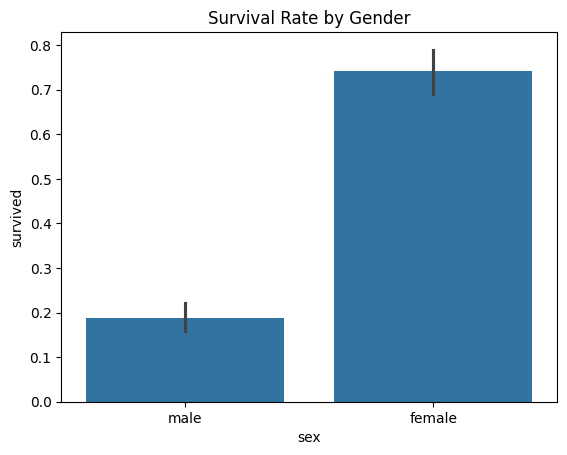

In [8]:
sns.barplot(x="sex",y="survived",data=df)
plt.title("Survival Rate by Gender")
plt.show()

In [9]:
#Survial Rate by gender: More females survied then male

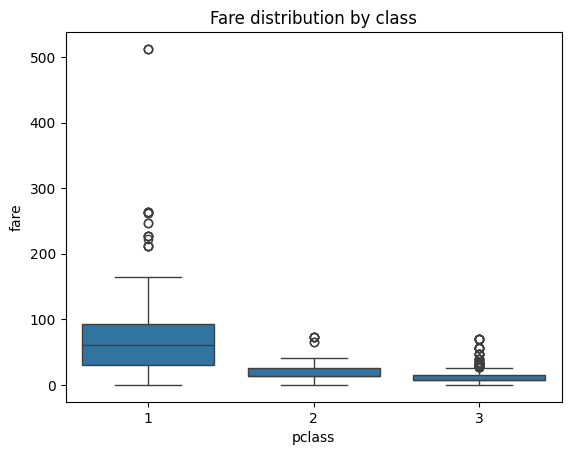

In [10]:
sns.boxplot(x="pclass",y="fare",data=df)
plt.title("Fare distribution by class")
plt.show()

In [11]:
# Class 1 people paid more fare

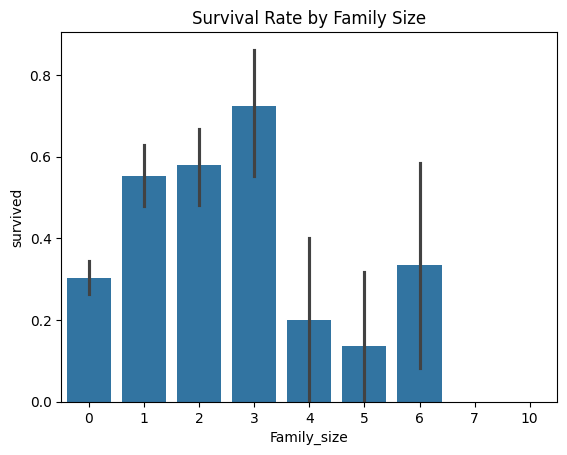

In [12]:
df["Family_size"]=df["sibsp"]+df["parch"]
sns.barplot(x="Family_size",y="survived",data=df)
plt.title("Survival Rate by Family Size")
plt.show()


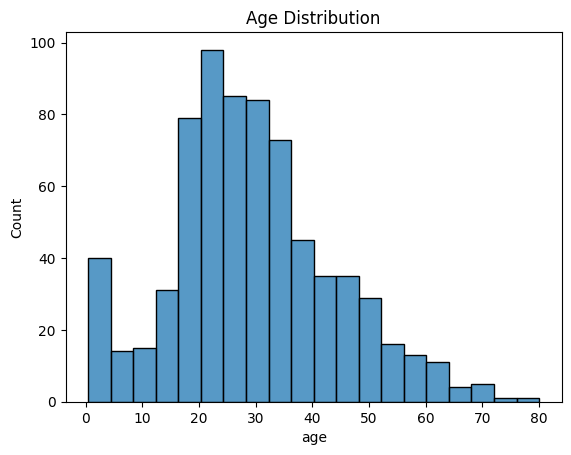

In [13]:
sns.histplot(data=df, x="age",bins=20)
plt.title("Age Distribution")
plt.show()

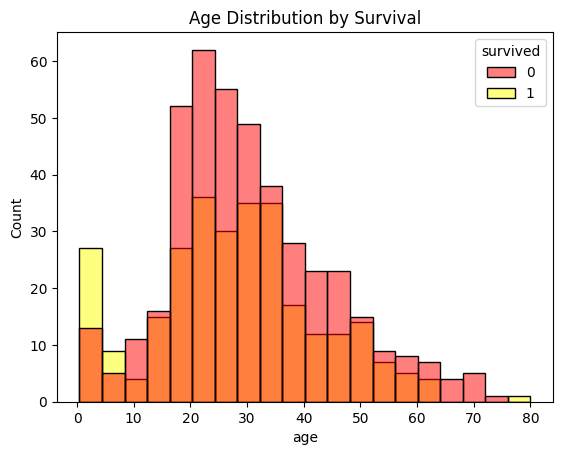

In [14]:
sns.histplot(data=df, x="age",hue="survived",palette=["red","yellow"])
plt.title("Age Distribution by Survival")
plt.show()

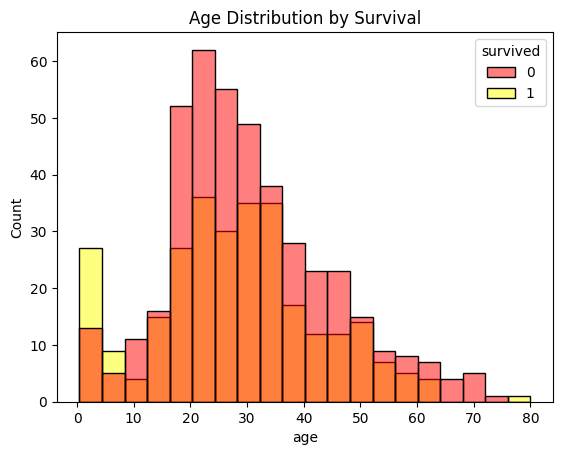

In [15]:
sns.histplot(data=df, x="age",hue="survived",palette=["red","yellow"],bins=20)
plt.title("Age Distribution by Survival")
plt.show()

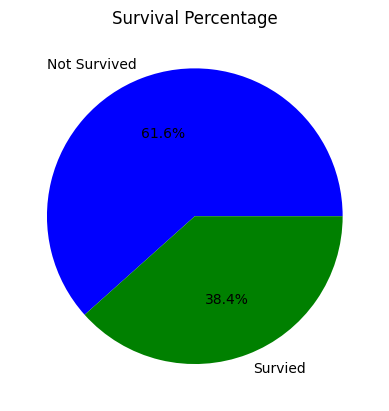

In [16]:
survival=df["survived"].value_counts()
plt.pie(survival,labels=["Not Survived","Survied"],autopct="%1.1f%%",colors=["blue","green"])
plt.title("Survival Percentage")
plt.show()

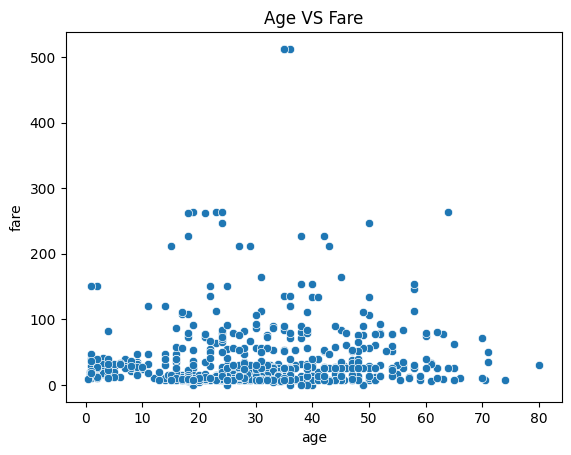

In [17]:
sns.scatterplot(x="age",y="fare",data=df)
plt.title("Age VS Fare")
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [20]:
df["embarked"].fillna("S",inplace=True)

In [21]:
df["deck"].fillna("Unknown",inplace=True)

/tmp/ipykernel_10351/4037492315.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["deck"].fillna("Unknown",inplace=True)


In [22]:
df.drop(["class","who","adult_male","deck","embark_town","alive"],axis=1,inplace=True)

In [50]:
df["sex"]=df["sex"].map({"male":0,"female":1})
df["embarked"]=df["embarked"].map({"S":0,"C":1,"Q":2})
df["alone"]=df["alone"].map({True:1,False:0})
df.fillna(0, inplace=True)

In [51]:
x=df.drop("survived",axis=1)
y=df["survived"]

In [58]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
    )

In [59]:

model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [60]:
y_pred=model.predict(x_test)

In [61]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.7374301675977654


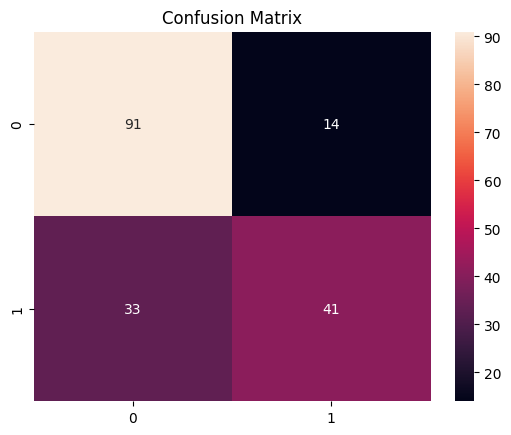

In [63]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.show()